<a href="https://colab.research.google.com/github/Mariamonsalve1305/MariaGeomatica/blob/main/Proyecto1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introducción

**evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. Para ello se trabajara con dos dataset reales de TomTom Traffic Index y OECD Cities.

---
## 🧩 Primer paso: Cargar y explorar

**Conocer la estrcutura del Dataset como sus atributos y tipos de datos**.


In [ ]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
# mostrar las primeras 5 filas de traffic
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
# mostrar las primeras 5 filas de eco
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.


In [ ]:
# Examinar la estructura de traffic
traffic.info()
traffic.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


**Se logro evidenciar que:**

- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` son de tipo object las cuales deben convertirse a (string)
- no existen datos nulo existe un total de datos 1004464 para todas los atributos.

In [ ]:
# Examinar la estructura de eco
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, 'PM2.5 (µg/m³)' y 'Population (M)' son datos tipo Object que deberian ser float64 ya que no se reconocerian como numero
- no existen datos nulo existe un total de datos 30 para todas los atributos
- revisar si existen valores "falsos nulos" como ceros, celdas vacías "" o textos como "Unknown" que el sistema no detecta automáticamente como nulos pero que afectan el análisis.

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**se identificó que las siguientes columnas necesitan renombrarse:**

    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`



In [ ]:
# Estandarizar los nombres de las columnas de traffic
traffic =traffic.rename(columns={'Country':'country',
                                 'UpdateTimeUTC':'update_time_utc',
                                'City':'city',
                                 'JamsDelay':'jams_delay',
                                 'TrafficIndexLive':'traffic_index_live',
                                 'JamsLengthInKms':'jams_length_in_kms',
                                 'JamsCount':'jams_count',
                                 'TrafficIndexWeekAgo':'traffic_index_week_ago',
                                 'UpdateTimeUTCWeekAgo':'update_time_utc_week_ago',
                                 'TravelTimeLivePer10KmsMins':'travel_time_live_per_10_kms_mins',
                                 'TravelTimeHistoricPer10KmsMins':'travel_time_historic_per_10_kms_mins',
                                 'MinsDelay':'mins_delay'
                                })
traffic.columns = traffic.columns.str.lower()
# verificacion de los cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10_kms_mins',
       'travel_time_historic_per_10_kms_mins', 'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
eco =eco.rename(columns={'Year':'year','Unemployment %':'unemployment_pct','City':'city','Country':'country','Population (M)':'population_m','PM2.5 (μg/m³)':'pm2.5_level','City GDP/capita':'city_gdp_capita'})
eco.columns = eco.columns.str.lower()
# verificacion de los cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm2.5_level', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Tranformar los atributos que se identificaron con problemas en el tipo de dato y caracteres:**

- columna de fecha de `traffic` a formato `datetime`.
- En el dataset `eco`, limpiar los valores numéricos:
    - En `city_gdp_capita`: eliminacion de separadores de miles (`.`) y reemplazar por comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: eliminar el símbolo de porcentaje (`%`) y reemplazar las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplazar las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'])
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'])

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                                Non-Null Count    Dtype         
---  ------                                --------------    -----         
 0   country                               1004464 non-null  object        
 1   city                                  1004464 non-null  object        
 2   update_time_utc                       1004464 non-null  datetime64[ns]
 3   jams_delay                            1004464 non-null  float64       
 4   traffic_index_live                    1004464 non-null  float64       
 5   jams_length_in_kms                    1004464 non-null  float64       
 6   jams_count                            1004464 non-null  float64       
 7   traffic_index_week_ago                1004464 non-null  float64       
 8   update_time_utc_week_ago              1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10_kms_mins      1004464 

In [ ]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.').astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m']*1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm2.5_level       30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm2.5_level,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Filtrar los registros para el año 2024.

In [ ]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year
# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year']==2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm2.5_level,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. es necesario calcular los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.



In [ ]:
# 1. Definir las listas (sin las comillas al usarlas abajo)
groups_cols = ["city", "country", "year"]

prom_metrics = [
    "jams_delay",
    "traffic_index_live",
    "jams_length_in_kms",
    "jams_count",
    "mins_delay",
    "travel_time_live_per_10_kms_mins",
    "travel_time_historic_per_10_kms_mins"
]

# 2. Aplicamos el agrupamiento
# Eliminamos las comillas de groups_cols y prom_metrics para que use las listas
traffic_city_year_2024 = traffic_2024.groupby(groups_cols)[prom_metrics].mean().reset_index()

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [ ]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


Se puede observa que La ciudad con el mayor tiempo promedio de tráfico es ciudad de Mexico seguido Tokyo y New York.


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets realizando un join de manera que se pueda tener informacion integrada de ambos en una sola tabla, identificando el id unico y/o la llave primaria.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.


In [ ]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','year',"jams_delay", "traffic_index_live", "jams_length_in_kms", "jams_count", "mins_delay", "travel_time_live_per_10_kms_mins", "travel_time_historic_per_10_kms_mins"]

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm2.5_level','population_m']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')

# Mostrar las primeras 5 filas
merged.head(5)

,city,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,city_gdp_capita,unemployment_pct,pm2.5_level,population_m
0,belo-horizonte,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6.1
1,bogota,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11.3
2,brasilia,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4.8
3,buenos-aires,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15.4
4,curitiba,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3.7



---

## 🧩Paso 6: Visualización y análisis de relaciones

**visualizar patrones**.
Los gráficos ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.


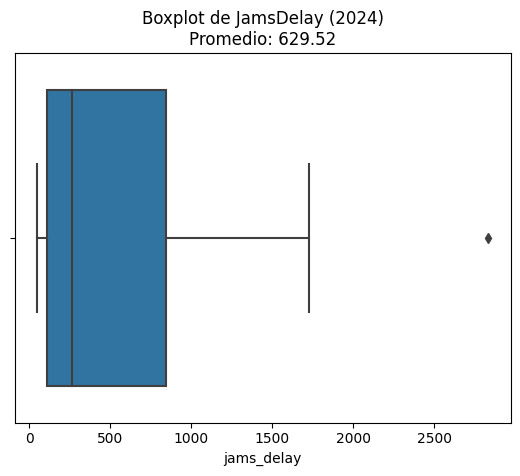

In [ ]:
# boxplot para observar el comportamiento de los minutos de congestion JamsDelay
sns.boxplot(data= merged, x='jams_delay',showmeans=True)
# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


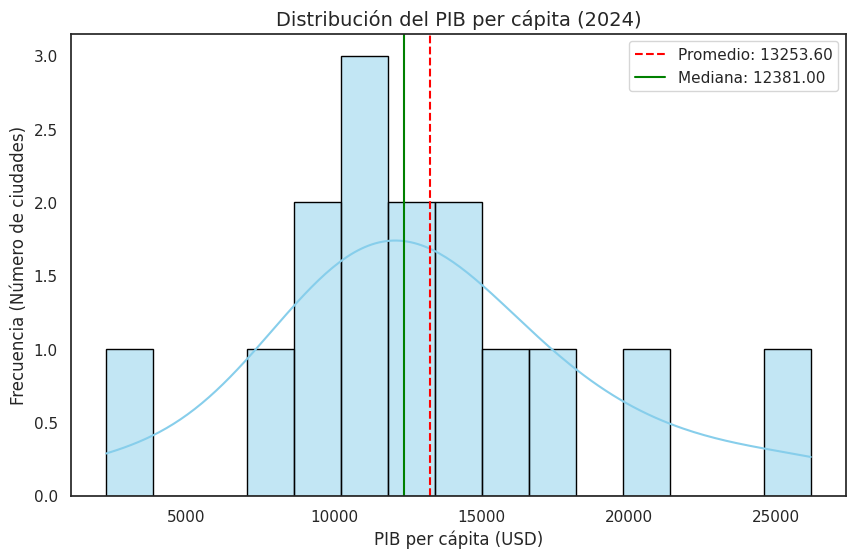

In [ ]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)

# Configuración de estilo
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# Calcular promedio y mediana
mean_gdp = merged['city_gdp_capita'].mean()
median_gdp = merged['city_gdp_capita'].median()

# Crear histograma con curva de densidad (KDE)
sns.histplot(merged['city_gdp_capita'], bins=15, kde=True, color='skyblue', edgecolor='black')

# Añadir líneas de referencia para el análisis
plt.axvline(mean_gdp, color='red', linestyle='--', label=f'Promedio: {mean_gdp:.2f}')
plt.axvline(median_gdp, color='green', linestyle='-', label=f'Mediana: {median_gdp:.2f}')

# Títulos y etiquetas
plt.title('Distribución del PIB per cápita (2024)', fontsize=14)
plt.xlabel('PIB per cápita (USD)')
plt.ylabel('Frecuencia (Número de ciudades)')
plt.legend()

plt.show()

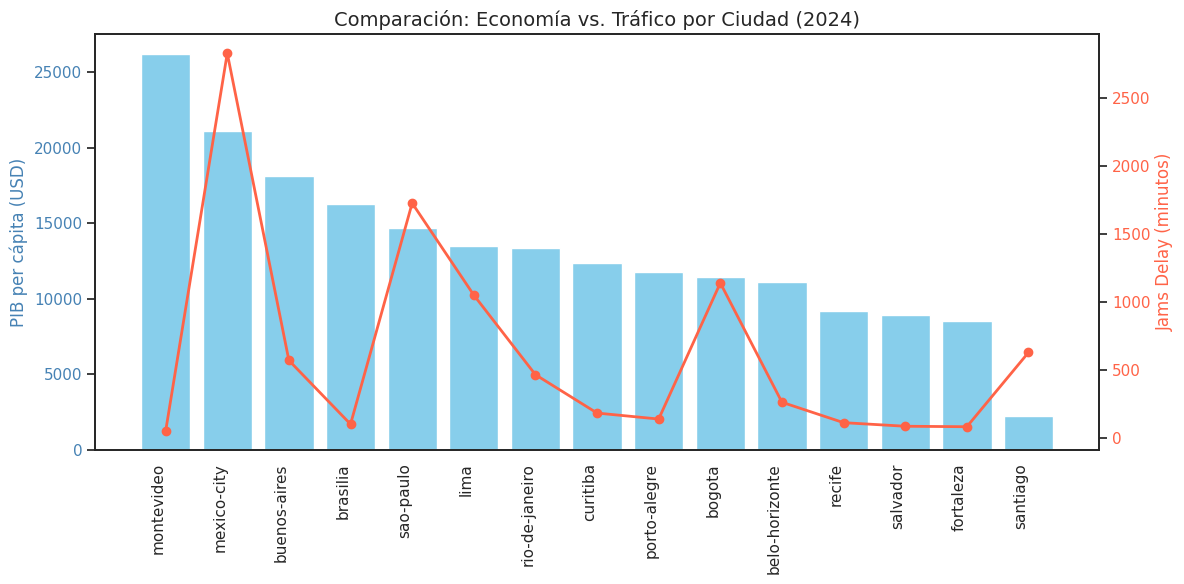

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
# 1. Preparar los datos (ordenar por PIB ayuda a ver patrones)
merged_sorted = merged.sort_values('city_gdp_capita', ascending=False)

# 2. Crear la figura y el primer eje (PIB)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras para el PIB (Eje izquierdo)
color_gdp = 'skyblue'
ax1.bar(merged_sorted['city'], merged_sorted['city_gdp_capita'], color=color_gdp, label='PIB per cápita')
ax1.set_ylabel('PIB per cápita (USD)', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
plt.xticks(rotation=90, ha='right') # Rotar nombres de ciudades

# 3. Crear el segundo eje para el Tráfico (Eje derecho)
ax2 = ax1.twinx()
color_traffic = 'tomato'
# Usamos una línea con puntos para que no se encime con las barras
ax2.plot(merged_sorted['city'], merged_sorted['jams_delay'], color=color_traffic, marker='o', linewidth=2, label='Jams Delay')
ax2.set_ylabel('Jams Delay (minutos)', color='tomato', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tomato')

# 4. Título y ajustes finales
plt.title('Comparación: Economía vs. Tráfico por Ciudad (2024)', fontsize=14)
fig.tight_layout()
plt.show()

plt.show()

La relacion del PIB no se encuentra relacionado con los retrasos del trafico de una manera clara,  si bien montevideo representa el PIB mas alto y sus niveles de trafico son bajos podriamos decir que tiene un indicador eficiente (movilidad eficiente y trafico eficiente), por otro lado Ciudad de Mexico tiene en pico ambos indicadores lo cual demostraria un deficit en la infraestructura vial por lo cual puede considerarse la inversion en infraestructura de transporte, y Santiago por otro lado al final de la grafica representa el PIB mas bajo y el trafico superior lo cual indica: alta congestión y baja productividad económica.

Este tipo de grafico ayuda a identificar tendenencias y comparar dos variables al mismo tiempo.


---

## 🧩Paso 7: Exportar y documentar resultados

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.


In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

# 🧾 Resumen ejecutivo

**Contexto & objetivo:**  
Tras analizar los datos de 2024, se observa que no existe una relación lineal clara ni definida entre el PIB per cápita y la congestión vehicular. En la gráfica, la línea de tendencia de los minutos de retraso (Jams Delay) no presenta un patrón constante frente a las barras del PIB; por el contrario, se aprecian picos de congestión drásticos en ciudades con niveles de riqueza muy distintos.

Es correcto concluir que una economía sólida no garantiza una movilidad excelente (como en Ciudad de México), así como un PIB bajo no asegura fluidez vial (como en Santiago). Asimismo, ciudades como Bogotá, São Paulo y Lima presentan niveles de congestión críticos a pesar de tener un PIB medio o bajo. Este fenómeno sugiere la presencia de "deseconomías de aglomeración", donde el tiempo perdido en el tráfico actúa como un freno a la productividad potencial de los ciudadanos.

Variables analizadas: Ciudad, año, PIB per cápita (city_gdp_capita) y retraso por tráfico (Jams Delay).  


**Cobertura de datos:**  
- el analisis corresponde al año 2024, Paises de Latinoamerica, y las ciudades resultado de esta union y analisis mediante metodologia Inner fueron 15: belo-horizonte, bogota, Brasilia, buenos-aires, Curitiba, fortaleza, lima, mexico-city, Montevideo, porto-alegre, recife
rio-de-janeiro, salvador, Santiago y sao-paulo

**Metodología (alto nivel):**  
- Es primordial al empezar a hacer el analisis el cargo de los datos, y el importe de las librerias, la exploracion de los dos diferentes datasets con el fin de identificar columnas claves, tipos de datos y variables de cada uno en general dar un vistazo al diccionario de datos, realizar el renombre de las columnas que signican lo mismo pero no estan igualmente escritas en su encabezado, corregir los tipos de datos pasar de un dato object en uno que corresponde a fecha y recategorizarlo correctamente a datetime como corresponde esto es vital ya que de acuerdo al tipo de dato puedo realizar las operaciones matematicas filtros que requiero sin que esto me modifique las metricas y sean erroneos los resultados que pase ante un informe.
  
- Una vez se cumplen los pasos anteriores procedemos a hacer un join con los atributos claves en comun de ambas tablas, en este caso agrupar por los atributos que quiero ver los resultados que en este caso fueron Ciudad y Año, y posteriormente identificar el tipo de join como el resultado es unicamente la informacion que se presente en ambos datasets se utilizo el Inner Join, si el resultado hubiese sido otro diferente como por ejemplo todos los resultados del dataset de traffic y los que tengan match con el dataseet eco se hubiese empleado un Left join.

- es importante mencionar que para las visualizaciones de este resultado de merge mediante el grafico de boxplot el cual es similar a  una caja de bigotes se pudo evidenciar comportamientos interesantes en la grafica y a rasgo rapido la revision que requieren.


**Hallazgos iniciales:**  
- Bogota lidera las estadisticas de congestion de manera preocupante; El mayor retrado acumulado  y lentitud al recorrer 10km toma casi 25 minutos, por otro lado la eficiencia en diseño vial y urbano de brasilia y buenos aires lo anterior porque mantienen tiempos de viaje cortos (13.3min/10Km). como datos importante  aresaltar sobre la calidad de aire en PM2.5 Level en donde Belo Horizonte apunta aunque no se relaciona esto directamente con el trafico, pueden existir otros factores como zonas industriales de alto impacto de manera local y directa.
- Existen datos atípicos, muy por encima que la mayoría de datos se encuentran en el Q3 y Q4, así mismo que la mediana es un valor aproximado a 250 en Jams delay y el promedio 629.52, lo cual indica que es importante realizar una revision a esos valores atípicos de manera de definir si es necesario recalcularlos o eliminarlos del análisis.


**Recomendaciones**  

Ante las ciudades mas criticas con congestiones viales, se puede realizar acciones empresariales en cuando a escalonamiento de hoarios laborales y/o teletrabajo.
En cuando a los datos se requiere revision y/o refinamiento en la calidad, de acuerdo a la visualizacion BoxPlot en donde se evidencia los valores atipicos promedio de 629 y mediana de 250 en Jams Delay lo cual no se encuentran en un rango estos dos.

Acción de Inversión: Priorizar la inversión en Infraestructura Inteligente (ITS) sobre la construcción de nuevas vías. En ciudades como Ciudad de México o Santiago, donde la riqueza no garantiza fluidez, la solución debe ser tecnológica (semáforos inteligentes, gestión de incidentes en tiempo real) para optimizar la red existente.
